In [29]:

import pandas as pd
import numpy as np
from pathlib import Path

ORIG_STATES = ["Market","Yield curve","Oil","Copper","Monetary policy","Volatility","Stock-bond"]

CANDIDATE_MAP = {
    "usd_trade_weighted_broad_z_wins":  "USD broad",
    "breakeven_inflation_10y_z_wins":   "Breakeven 10y",
    "high_yield_oas_z_wins":            "HY OAS",
    "umich_consumer_sentiment_z_wins":  "UMich",
    "real_yield_10y_z_wins":            "Real 10y",
}

def _ensure_month_period(df, month_col="Month"):
    df = df.copy()
    if month_col not in df.columns:
        for cand in ["month","MONTH","Date","DATE","date","period","Period"]:
            if cand in df.columns:
                df["Month"] = pd.to_datetime(df[cand], errors="coerce").dt.to_period("M")
                break
        else:
            raise ValueError("Could not find a usable date column to build 'Month'.")
    if not isinstance(df["Month"].dtype, pd.PeriodDtype):
        df["Month"] = pd.to_datetime(df["Month"], errors="coerce").dt.to_period("M")
    return (df.loc[df["Month"].notna()]
              .sort_values("Month")
              .drop_duplicates(subset=["Month"], keep="last"))

orig_df = None

if "orig" in globals():
    needed = ["Month"] + [c for c in ORIG_STATES if c in globals()["orig"].columns]
    if all(c in globals()["orig"].columns for c in ["Month"]) and len(needed) >= 2:
        orig_df = globals()["orig"][needed].copy()

if orig_df is None and "dfp" in globals():
    dfp2 = _ensure_month_period(globals()["dfp"], "Month")
    cols = ["Month"] + [c for c in ORIG_STATES if c in dfp2.columns]
    if len(cols) >= 2:
        orig_df = dfp2[cols].copy()

if orig_df is None:
    STATE_FILE_GUESS = globals().get("STATE_VAR_PATH", None)
    if STATE_FILE_GUESS and Path(STATE_FILE_GUESS).exists():
        try:
            df_try = pd.read_excel(STATE_FILE_GUESS)
        except Exception:
            df_try = pd.read_csv(STATE_FILE_GUESS)
        df_try = _ensure_month_period(df_try, "Month")
        rename_map = {}
        for w in ORIG_STATES:
            for c in df_try.columns:
                if c.lower().strip() == w.lower():
                    rename_map[c] = w
        df_try = df_try.rename(columns=rename_map)
        cols = ["Month"] + [c for c in ORIG_STATES if c in df_try.columns]
        if len(cols) >= 2:
            orig_df = df_try[cols].copy()

if orig_df is None:
    raise NameError("Could not build originals block. Provide 'orig' or 'dfp' or a readable state file with the 7 originals.")

if "macro_z" not in globals():
    raise NameError("macro_z is not defined. Please create it (must contain *_z_wins columns).")

if "Month" in macro_z.columns:
    mz = macro_z.copy()
    if not isinstance(mz["Month"].dtype, pd.PeriodDtype):
        mz["Month"] = pd.to_datetime(mz["Month"], errors="coerce").dt.to_period("M")
else:
    mz = macro_z.copy()
    mz["Month"] = pd.to_datetime(mz.index, errors="coerce").to_period("M")

cand_cols_in_mz = [k for k in CANDIDATE_MAP.keys() if k in mz.columns]
cand_df = mz[["Month"] + cand_cols_in_mz].rename(columns=CANDIDATE_MAP).copy()

features_all = (
    pd.merge(orig_df, cand_df, on="Month", how="inner")
      .sort_values("Month")
      .set_index("Month")
)
if not isinstance(features_all.index, pd.PeriodIndex):
    features_all.index = pd.to_datetime(features_all.index, errors="coerce").to_period("M")
features_all = features_all.sort_index()

baseline_cols = [c for c in ORIG_STATES if c in features_all.columns]
cand_cols     = [CANDIDATE_MAP[k] for k in cand_cols_in_mz if CANDIDATE_MAP[k] in features_all.columns and CANDIDATE_MAP[k] not in baseline_cols]

print(f"features_all shape: {features_all.shape}")
print("Baseline cols found:", baseline_cols)
print("Candidate cols found:", cand_cols)
print("Index range:", features_all.index.min(), "→", features_all.index.max())


features_all shape: (214, 12)
Baseline cols found: ['Market', 'Yield curve', 'Oil', 'Copper', 'Monetary policy', 'Volatility', 'Stock-bond']
Candidate cols found: ['USD broad', 'Breakeven 10y', 'HY OAS', 'UMich', 'Real 10y']
Index range: 2006-06 → 2024-12


In [30]:

import numpy as np
import pandas as pd

EPS_SR  = 1e-6   
RHO_TOL = 0.0    
MIN_QS  = 3     

def _require(name, obj):
    if obj is None:
        raise NameError(f"Required object '{name}' is not defined in the notebook.")
def _to_period_m_index(idx):
    if isinstance(idx, pd.PeriodIndex):
        return idx.asfreq("M")
    if isinstance(idx, pd.DatetimeIndex):
        return idx.to_period("M")
    return pd.to_datetime(idx, errors="coerce").to_period("M")

_require("features_all", globals().get("features_all"))
_require("baseline_cols", globals().get("baseline_cols"))
_require("cand_cols", globals().get("cand_cols"))
_require("sec_ret_daily", globals().get("sec_ret_daily"))
_require("sec_ret_monthly", globals().get("sec_ret_monthly"))
_require("assets", globals().get("assets"))
_require("months_bt", globals().get("months_bt"))
_require("TRAIN_START", globals().get("TRAIN_START"))
_require("TRAIN_END", globals().get("TRAIN_END"))

if not isinstance(months_bt, pd.PeriodIndex):
    months_bt = pd.PeriodIndex(months_bt, freq="M")

features_all = features_all.copy()
features_all.index = _to_period_m_index(features_all.index)

def _make_buckets(ranked_idx: pd.Index) -> dict[int, np.ndarray]:
    n = len(ranked_idx)
    if n == 0:
        return {q: np.array([]) for q in range(1,6)}
    if n >= 25:
        k20 = max(int(np.floor(0.20 * n)), 1)
        q1  = ranked_idx[:k20].values
        q5  = ranked_idx[-k20:].values
        mid = ranked_idx[k20:-k20].values
        if len(mid) >= 3:
            q2, q3, q4 = np.array_split(mid, 3)
        else:
            q2, q3, q4 = np.array([]), mid, np.array([])
    else:
        parts = np.array_split(ranked_idx.values, 5)  
        q1, q2, q3, q4, q5 = parts
    return {1:q1, 2:q2, 3:q3, 4:q4, 5:q5}

def rank_similar_months_euclid_fixed(F_full: pd.DataFrame, F_train: pd.DataFrame, T: pd.Period) -> pd.Index:
    if T not in F_full.index:
        prior = F_full.index[F_full.index < T]
        if len(prior) == 0:
            return pd.Index([])
        T = prior.max()
    C = F_train.dropna(how="any")
    if C.empty:
        return pd.Index([])

    cols = C.columns
    xT = F_full.loc[T, cols]
    if xT.isna().any():
        return pd.Index([])

    X = C[cols].to_numpy(dtype=float, copy=False)
    x = xT.to_numpy(dtype=float, copy=False)[None, :]
    d = np.linalg.norm(X - x, axis=1)
    order = np.argsort(d)
    return C.index[order]

def _diag(F_full, F_train):
    print(f"Features range: {F_full.index.min()} → {F_full.index.max()} (rows={len(F_full)})")
    print(f"Train slice  : {F_train.index.min()} → {F_train.index.max()} (rows={len(F_train)})")
    print("Complete rows in TRAIN (no NaNs):", len(F_train.dropna(how='any')))
    try:
        if isinstance(sec_ret_monthly.index, pd.DatetimeIndex):
            smin = sec_ret_monthly.index.min().to_period("M")
            smax = sec_ret_monthly.index.max().to_period("M")
        elif isinstance(sec_ret_monthly.index, pd.PeriodIndex):
            smin, smax = sec_ret_monthly.index.min(), sec_ret_monthly.index.max()
        else:
            smin = pd.to_datetime(sec_ret_monthly.index, errors="coerce").min().to_period("M")
            smax = pd.to_datetime(sec_ret_monthly.index, errors="coerce").max().to_period("M")
        print(f"Sectors monthly range: {smin} → {smax}")
    except Exception:
        pass
    print("OOS months_bt:", months_bt.min(), "→", months_bt.max(), "(n=", len(months_bt), ")")

def _ann_sr(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    s = np.nanstd(x)
    return float((np.nanmean(x)/s)*np.sqrt(252.0)) if s > 0 else np.nan

def evaluate_monotonicity_and_ls_sr_euclid(selected_cols: list[str], min_quintiles: int = MIN_QS, verbose=False) -> tuple[float, float]:
    """
    Returns:
        (mean Spearman monotonicity across months, LS (Q1-Q5) daily ann. Sharpe)
    """
    F_full = features_all[selected_cols].copy()
    mask_tr = (F_full.index >= TRAIN_START) & (F_full.index <= TRAIN_END)
    F_train = F_full.loc[mask_tr]
    if F_train.dropna(how="any").empty:
        if verbose: _diag(F_full, F_train)
        return np.nan, np.nan

    rhos = []
    q1_daily_all, q5_daily_all = [], []

    for i in range(len(months_bt)-1):
        cur_per, nxt_per = months_bt[i], months_bt[i+1]

        ranked = rank_similar_months_euclid_fixed(F_full, F_train, cur_per)
        if len(ranked) == 0:
            continue
        buckets = _make_buckets(ranked)

        dts = sec_ret_daily.index[sec_ret_daily.index.to_period('M') == nxt_per]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        q_ret = {}
        q_port_daily = {}

        for q in [1,2,3,4,5]:
            months_sim = buckets[q]
            if len(months_sim) == 0:
                q_ret[q] = np.nan
                q_port_daily[q] = None
                continue

            idx_sim_next = pd.PeriodIndex(months_sim, freq='M') + 1
            signs = {}
            for a in assets:
                r = sec_ret_monthly.loc[sec_ret_monthly.index.intersection(idx_sim_next), a]
                signs[a] = np.sign(r.mean()) if not r.empty else 0

            w = pd.Series(signs, index=assets, dtype=float)
            port_daily = (Rm * w).mean(axis=1)

            q_port_daily[q] = port_daily.to_numpy(dtype=float)
            q_ret[q] = float((1.0 + port_daily).prod() - 1.0)

        qs, vals = zip(*[(k, v) for k, v in q_ret.items() if pd.notna(v)])
        if len(vals) >= min_quintiles and np.std(vals) > 0:
            rho = pd.Series(vals).corr(pd.Series(qs), method="spearman")
            if pd.notna(rho):
                rhos.append(rho)

        if (q_port_daily.get(1) is not None) and (q_port_daily.get(5) is not None):
            q1_daily_all.append(q_port_daily[1])
            q5_daily_all.append(q_port_daily[5])

    rho_mean = float(np.mean(rhos)) if rhos else np.nan
    if q1_daily_all and q5_daily_all:
        q1 = np.concatenate(q1_daily_all)
        q5 = np.concatenate(q5_daily_all)
        ls_sr = _ann_sr(q1 - q5)
    else:
        ls_sr = np.nan

    if verbose:
        _diag(F_full, F_train)
        print(f"Monotonicity valid months: {len(rhos)} | mean rho={rho_mean:.4f} | LS SR={ls_sr:.4f}")

    return rho_mean, ls_sr

def in_sample_collinearity_guard(cols_selected: list[str], cand: str, thresh: float = 0.95) -> bool:
    panel = features_all[cols_selected + [cand]].dropna()
    if len(panel) < 5:
        return False
    corrs = panel.corr().abs()
    mx = corrs.loc[cand, cols_selected].max()
    return bool(mx >= thresh)

def run_forward_selection_euclid(
    baseline_cols: list[str],
    cand_cols: list[str],
    eps_sr: float = EPS_SR,
    rho_tol: float = RHO_TOL,
    use_collinearity_guard: bool = True,
    collinear_thresh: float = 0.95,
    verbose: bool = True
):
    current = baseline_cols[:]
    base_rho, base_ls_sr = evaluate_monotonicity_and_ls_sr_euclid(current, verbose=verbose)
    if verbose:
        print(f"\nBaseline (Euclidean): rho={base_rho:.4f} | LS SR={base_ls_sr:.4f}")

    remaining = [c for c in cand_cols if c not in current]
    history = []

    while remaining:
        trials = []
        for c in remaining:
            if use_collinearity_guard and in_sample_collinearity_guard(current, c, collinear_thresh):
                trials.append({"k": len(current)+1, "trial_added": c,
                               "rho": np.nan, "ls_sr": np.nan, "d_ls_sr": np.nan, "d_rho": np.nan,
                               "skip": "collinearity"})
                continue

            test_cols = current + [c]
            rho, ls_sr = evaluate_monotonicity_and_ls_sr_euclid(test_cols, verbose=False)
            trials.append({
                "k": len(test_cols),
                "trial_added": c,
                "rho": rho,
                "ls_sr": ls_sr,
                "d_ls_sr": (ls_sr - base_ls_sr) if pd.notna(ls_sr) and pd.notna(base_ls_sr) else np.nan,
                "d_rho":   (rho - base_rho)     if pd.notna(rho)   and pd.notna(base_rho)   else np.nan,
                "skip": ""
            })

        history.extend(trials)

        ok = [t for t in trials
              if t.get("skip","") == ""
              and pd.notna(t["d_ls_sr"]) and (t["d_ls_sr"] > eps_sr)
              and pd.notna(t["rho"]) and pd.notna(base_rho) and (t["rho"] >= base_rho - rho_tol)]

        if not ok:
            if verbose:
                print("No candidate improves LS Sharpe (and preserves monotonicity). Stopping.")
            break

        ok.sort(key=lambda z: (z["d_ls_sr"], z["rho"], z["d_rho"]), reverse=True)
        best = ok[0]
        chosen = best["trial_added"]

        current.append(chosen)
        remaining.remove(chosen)

        if verbose:
            print(f" + Keeping '{chosen}' | LS SR: {best['ls_sr']:.4f} (Δ {best['d_ls_sr']:.4f}) | "
                  f"rho: {best['rho']:.4f} (Δ {best['d_rho']:.4f})")

        base_rho, base_ls_sr = best["rho"], best["ls_sr"]

    hist_df = pd.DataFrame(history).sort_values(["k","d_ls_sr","rho"], ascending=[True, False, False])
    if verbose:
        print("\nSelected variables (final):", current)
        print(f"Final (Euclidean): rho={base_rho:.4f} | LS SR={base_ls_sr:.4f}")
        try:
            display(hist_df.groupby("k").head(5)[["k","trial_added","rho","d_rho","ls_sr","d_ls_sr","skip"]])
        except Exception:
            print(hist_df.groupby("k").head(5)[["k","trial_added","rho","d_rho","ls_sr","d_ls_sr","skip"]].to_string(index=False))
    return current, hist_df, base_rho, base_ls_sr

selected_vars, selection_history, final_rho, final_ls_sr = run_forward_selection_euclid(
    baseline_cols=baseline_cols,
    cand_cols=cand_cols,
    eps_sr=EPS_SR,
    rho_tol=RHO_TOL,
    use_collinearity_guard=True,
    collinear_thresh=0.95,
    verbose=True
)


Features range: 2006-06 → 2024-12 (rows=214)
Train slice  : 2006-06 → 2018-12 (rows=146)
Complete rows in TRAIN (no NaNs): 146
Sectors monthly range: 1995-01 → 2025-08
OOS months_bt: 2019-01 → 2024-12 (n= 72 )
Monotonicity valid months: 71 | mean rho=-0.1150 | LS SR=0.7473

Baseline (Euclidean): rho=-0.1150 | LS SR=0.7473
No candidate improves LS Sharpe (and preserves monotonicity). Stopping.

Selected variables (final): ['Market', 'Yield curve', 'Oil', 'Copper', 'Monetary policy', 'Volatility', 'Stock-bond']
Final (Euclidean): rho=-0.1150 | LS SR=0.7473


,k,trial_added,rho,d_rho,ls_sr,d_ls_sr,skip
0,8,USD broad,-0.043117,0.071839,0.464969,-0.282373,
4,8,Real 10y,0.033012,0.147968,0.005966,-0.741376,
3,8,UMich,-0.020779,0.094177,-0.422057,-1.169398,
1,8,Breakeven 10y,0.032697,0.147653,-0.458156,-1.205498,
2,8,HY OAS,0.063453,0.178410,-0.488850,-1.236191,


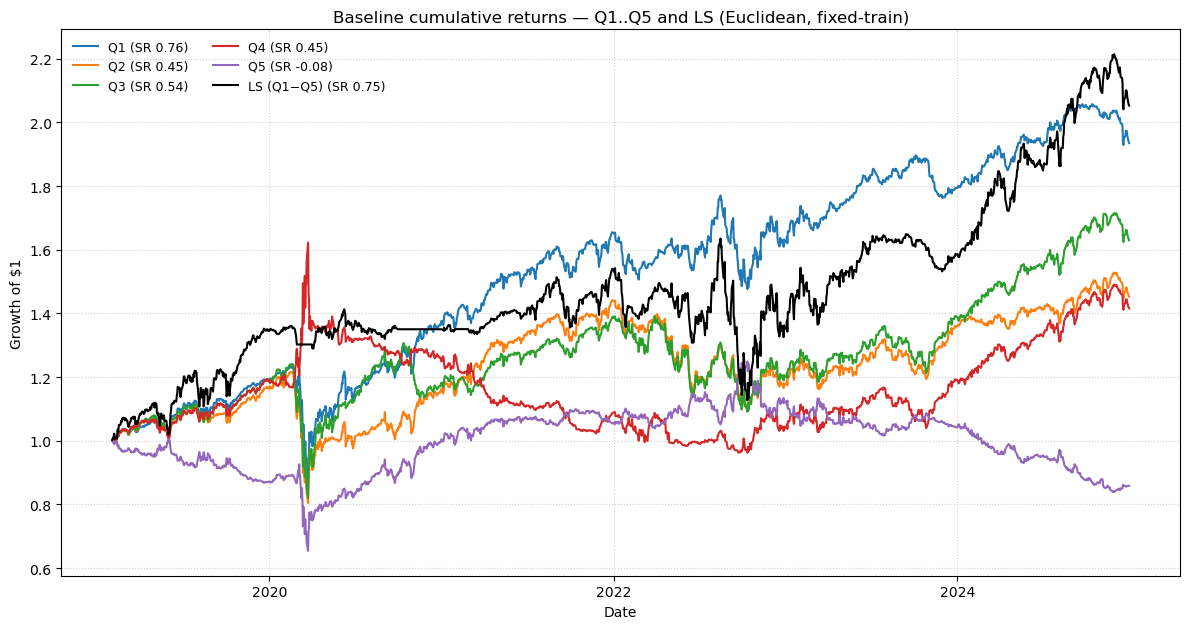

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def _to_period_m_index(idx):
    if isinstance(idx, pd.PeriodIndex): return idx.asfreq("M")
    if isinstance(idx, pd.DatetimeIndex): return idx.to_period("M")
    return pd.to_datetime(idx, errors="coerce").to_period("M")

def _make_buckets(ranked_idx: pd.Index) -> dict[int, np.ndarray]:
    n = len(ranked_idx)
    if n == 0:
        return {q: np.array([]) for q in range(1,6)}
    if n >= 25:
        k20 = max(int(np.floor(0.20 * n)), 1)
        q1  = ranked_idx[:k20].values
        q5  = ranked_idx[-k20:].values
        mid = ranked_idx[k20:-k20].values
        q2, q3, q4 = np.array_split(mid, 3) if len(mid) >= 3 else (np.array([]), mid, np.array([]))
    else:
        parts = np.array_split(ranked_idx.values, 5) 
        q1, q2, q3, q4, q5 = parts
    return {1:q1, 2:q2, 3:q3, 4:q4, 5:q5}

def rank_similar_months_euclid_fixed(F_full: pd.DataFrame, F_train: pd.DataFrame, T: pd.Period) -> pd.Index:
    if T not in F_full.index:
        prior = F_full.index[F_full.index < T]
        if len(prior) == 0:
            return pd.Index([])
        T = prior.max()
    C = F_train.dropna(how="any")
    if C.empty:
        return pd.Index([])
    cols = C.columns
    xT = F_full.loc[T, cols]
    if xT.isna().any():
        return pd.Index([])
    X = C[cols].to_numpy(dtype=float, copy=False)
    x = xT.to_numpy(dtype=float, copy=False)[None, :]
    d = np.linalg.norm(X - x, axis=1)
    order = np.argsort(d)
    return C.index[order]

def ann_sr(x: pd.Series | np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    s = np.nanstd(x)
    return float((np.nanmean(x)/s)*np.sqrt(252.0)) if s > 0 else np.nan

assert set(baseline_cols).issubset(set(features_all.columns)), "baseline_cols must be columns of features_all"
if not isinstance(months_bt, pd.PeriodIndex):
    months_bt = pd.PeriodIndex(months_bt, freq="M")

F_all = features_all.copy()
F_all.index = _to_period_m_index(F_all.index)
F_base = F_all[baseline_cols].copy()

mask_tr = (F_base.index >= TRAIN_START) & (F_base.index <= TRAIN_END)
F_train = F_base.loc[mask_tr]

ret_pairs_by_q = {q: [] for q in range(1,6)}  # each will collect (date, ret)

for i in range(len(months_bt)-1):
    cur_per, nxt_per = months_bt[i], months_bt[i+1]

    ranked = rank_similar_months_euclid_fixed(F_base, F_train, cur_per)
    if len(ranked) == 0:
        continue
    buckets = _make_buckets(ranked)

    dts = sec_ret_daily.index[sec_ret_daily.index.to_period('M') == nxt_per]
    if len(dts) == 0:
        continue
    Rm = sec_ret_daily.loc[dts, assets]

    for q in [1,2,3,4,5]:
        months_sim = buckets[q]
        if len(months_sim) == 0:
            q_daily = pd.Series(0.0, index=dts)
        else:
            idx_sim_next = pd.PeriodIndex(months_sim, freq='M') + 1
            signs = {}
            for a in assets:
                r = sec_ret_monthly.loc[sec_ret_monthly.index.intersection(idx_sim_next), a]
                signs[a] = np.sign(r.mean()) if not r.empty else 0
            w = pd.Series(signs, index=assets, dtype=float)
            q_daily = (Rm * w).mean(axis=1)

        ret_pairs_by_q[q].extend(list(q_daily.items()))

q_series = {q: pd.Series(dict(ret_pairs_by_q[q])).sort_index() for q in range(1,6)}
for q in q_series:
    q_series[q].index = pd.to_datetime(q_series[q].index)

common_idx = None
for q in q_series:
    common_idx = q_series[q].index if common_idx is None else common_idx.intersection(q_series[q].index)
for q in q_series:
    q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

ls_series = (q_series[1] - q_series[5]).rename("LS")

def cum(x): return (1.0 + x.fillna(0.0)).cumprod()

plt.figure(figsize=(12, 6.4))
colors = {1:"tab:blue", 2:"tab:orange", 3:"tab:green", 4:"tab:red", 5:"tab:purple"}

for q in [1,2,3,4,5]:
    sr = ann_sr(q_series[q].values)
    plt.plot(q_series[q].index, cum(q_series[q]), label=f"Q{q} (SR {sr:.2f})", color=colors[q])

sr_ls = ann_sr(ls_series.values)
plt.plot(ls_series.index, cum(ls_series), label=f"LS (Q1−Q5) (SR {sr_ls:.2f})", color="black")

plt.title("Baseline cumulative returns — Q1..Q5 and LS (Euclidean, fixed-train)")
plt.xlabel("Date"); plt.ylabel("Growth of $1")
plt.grid(ls=":", alpha=.6)
ax = plt.gca()
ax.legend(frameon=False, fontsize=9, ncols=2)
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


In [34]:

def run_backtest_sr(F_full: pd.DataFrame, F_train: pd.DataFrame) -> dict[str, float]:
    """Run Euclidean backtest and return SR for Q1 and Q5 only (same as graph)."""
    ret_pairs_by_q = {q: [] for q in range(1,6)}

    for i in range(len(months_bt)-1):
        cur_per, nxt_per = months_bt[i], months_bt[i+1]

        ranked = rank_similar_months_euclid_fixed(F_full, F_train, cur_per)
        if len(ranked) == 0:
            continue
        buckets = _make_buckets(ranked)

        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == nxt_per]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        for q in [1,2,3,4,5]:
            months_sim = buckets[q]
            if len(months_sim) == 0:
                q_daily = pd.Series(0.0, index=dts)
            else:
                idx_sim_next = pd.PeriodIndex(months_sim, freq="M") + 1
                signs = {}
                for a in assets:
                    r = sec_ret_monthly.loc[sec_ret_monthly.index.intersection(idx_sim_next), a]
                    signs[a] = np.sign(r.mean()) if not r.empty else 0
                w = pd.Series(signs, index=assets, dtype=float)
                q_daily = (Rm * w).mean(axis=1)
            ret_pairs_by_q[q].extend(list(q_daily.items()))

    q_series = {q: pd.Series(dict(ret_pairs_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        common_idx = q_series[q].index if common_idx is None else common_idx.intersection(q_series[q].index)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    return {
        "Q1_SR": ann_sr(q_series[1].values),
        "Q5_SR": ann_sr(q_series[5].values)
    }

F_all_base = features_all[baseline_cols].copy()
F_all_base.index = _to_period_m_index(F_all_base.index)
mask_tr = (F_all_base.index >= TRAIN_START) & (F_all_base.index <= TRAIN_END)
F_train_base = F_all_base.loc[mask_tr]

baseline_res = run_backtest_sr(F_all_base, F_train_base)
SR_Q1_base, SR_Q5_base = baseline_res["Q1_SR"], baseline_res["Q5_SR"]

print(f"Baseline Sharpe Ratios -> Q1: {SR_Q1_base:.3f}, Q5: {SR_Q5_base:.3f}")

candidate_vars = ["USD broad", "Breakeven 10y", "HY OAS", "UMich", "Real 10y"]  # your candidates

results = []
for var in candidate_vars:
    if var not in features_all.columns:
        continue
    cols = baseline_cols + [var]
    F_all_var = features_all[cols].copy()
    F_all_var.index = _to_period_m_index(F_all_var.index)
    mask_tr = (F_all_var.index >= TRAIN_START) & (F_all_var.index <= TRAIN_END)
    F_train_var = F_all_var.loc[mask_tr]

    res_var = run_backtest_sr(F_all_var, F_train_var)
    SR_Q1_new, SR_Q5_new = res_var["Q1_SR"], res_var["Q5_SR"]

    improves = (SR_Q1_new > SR_Q1_base) and (SR_Q5_new < SR_Q5_base)
    results.append({
        "Variable": var,
        "SR_Q1_base": SR_Q1_base,
        "SR_Q5_base": SR_Q5_base,
        "SR_Q1_new": SR_Q1_new,
        "SR_Q5_new": SR_Q5_new,
        "Improves monotonicity?": improves
    })

results_df = pd.DataFrame(results)
print(results_df)


Baseline Sharpe Ratios -> Q1: 0.760, Q5: -0.083
        Variable  SR_Q1_base  SR_Q5_base  SR_Q1_new  SR_Q5_new  \
0      USD broad    0.759598   -0.083336   0.862124   0.192604   
1  Breakeven 10y    0.759598   -0.083336   0.801370   1.235914   
2         HY OAS    0.759598   -0.083336   0.405586   1.277215   
3          UMich    0.759598   -0.083336   0.645247   1.193024   
4       Real 10y    0.759598   -0.083336   0.713615   0.873232   

   Improves monotonicity?  
0                   False  
1                   False  
2                   False  
3                   False  
4                   False  
